# Auxilliary

In [1]:
import os
from exp import runNSave, get_times_file, record_eye, record_fun3

# Config

In [2]:
path = "."
rules_files = [ os.path.join(path, "red", f"rules_red{nr}.n3") for nr in range(0, 2) ]
data_files = [ os.path.join(path, "red", "data", f"gen{size}_pt{pt}.n3") for size in [ 100, 200, 500, 700, 1000 ] for pt in [ 1, 2] ]
# data_files = [ os.path.join(path, "red", "data", "gen100_pt1.n3") ]

nr_runs = 5

# eye

In [3]:
times_fh = get_times_file(os.path.join(path, "red", "results"), 'eye')

query_file = os.path.join(path, "query_eye.n3")

for run in range(0, nr_runs):
    print("run:", run)
    
    for rules_file in rules_files:
        print("rules:", rules_file)
    
        for data_file in data_files:
            print("data:", data_file)
            
            rules_name = os.path.basename(rules_file)
            data_name = os.path.basename(data_file)
            
            eye_res_file = os.path.join(path, "red", "results", f"eye-{rules_name}-{data_name}.n3")
            
            netw_time, reas_time = runNSave(["eye", rules_file, data_file , "--query", query_file, "--nope"], eye_res_file)
            record_eye(times_fh, run, rules_name, data_name, netw_time, reas_time)

            times_fh.flush()
    
times_fh.close()

run: 0
rules: ./red/rules_red0.n3
data: ./red/data/gen100_pt1.n3
data: ./red/data/gen100_pt2.n3
data: ./red/data/gen200_pt1.n3
data: ./red/data/gen200_pt2.n3
data: ./red/data/gen500_pt1.n3
data: ./red/data/gen500_pt2.n3
data: ./red/data/gen700_pt1.n3
data: ./red/data/gen700_pt2.n3
data: ./red/data/gen1000_pt1.n3
data: ./red/data/gen1000_pt2.n3
rules: ./red/rules_red1.n3
data: ./red/data/gen100_pt1.n3
data: ./red/data/gen100_pt2.n3
data: ./red/data/gen200_pt1.n3
data: ./red/data/gen200_pt2.n3
data: ./red/data/gen500_pt1.n3
data: ./red/data/gen500_pt2.n3
data: ./red/data/gen700_pt1.n3
data: ./red/data/gen700_pt2.n3
data: ./red/data/gen1000_pt1.n3
data: ./red/data/gen1000_pt2.n3
run: 1
rules: ./red/rules_red0.n3
data: ./red/data/gen100_pt1.n3
data: ./red/data/gen100_pt2.n3
data: ./red/data/gen200_pt1.n3
data: ./red/data/gen200_pt2.n3
data: ./red/data/gen500_pt1.n3
data: ./red/data/gen500_pt2.n3
data: ./red/data/gen700_pt1.n3
data: ./red/data/gen700_pt2.n3
data: ./red/data/gen1000_pt1.n3
d

# fun3

In [5]:
from pathlib import Path
import sys
sys.path.insert(0, "../../")
from n3.to_py import run_py, save_py

In [6]:
times_fh = get_times_file(os.path.join(path, "red", "results"), 'fun3')

query_file = os.path.join(path, "query.n3")
code_file = os.path.join(path, "red", "results", "code_out.py")

for run in range(0, nr_runs):
    print("run:", run)
    
    for rules_file in rules_files:
        print("rules:", rules_file)
    
        for data_file in data_files:
            print("data:", data_file)
            
            rules_name = os.path.basename(rules_file)
            data_name = os.path.basename(data_file)
            
            fun3_res_file = os.path.join(path, "red", "results", f"fun3-{rules_name}-{data_name}.n3")
        
            # save_py(Path(query_file), Path(rules_file), Path(data_file), code_file, print_code=False, add_tracing=False, code_dir="../../../..")
            netw_time, gen_time, exec_time, reas_time = run_py(Path(query_file), Path(rules_file), Path(data_file), save_to=fun3_res_file)
            record_fun3(times_fh, run, rules_name, data_name, netw_time, reas_time, gen_time, exec_time)
    
        times_fh.flush()
    
times_fh.close()

run: 0
rules: ./red/rules_red0.n3
data: ./red/data/gen100_pt1.n3
data: ./red/data/gen100_pt2.n3
data: ./red/data/gen200_pt1.n3
data: ./red/data/gen200_pt2.n3
data: ./red/data/gen500_pt1.n3
data: ./red/data/gen500_pt2.n3
data: ./red/data/gen700_pt1.n3
data: ./red/data/gen700_pt2.n3
data: ./red/data/gen1000_pt1.n3
data: ./red/data/gen1000_pt2.n3
rules: ./red/rules_red1.n3
data: ./red/data/gen100_pt1.n3
data: ./red/data/gen100_pt2.n3
data: ./red/data/gen200_pt1.n3
data: ./red/data/gen200_pt2.n3
data: ./red/data/gen500_pt1.n3
data: ./red/data/gen500_pt2.n3
data: ./red/data/gen700_pt1.n3
data: ./red/data/gen700_pt2.n3
data: ./red/data/gen1000_pt1.n3
data: ./red/data/gen1000_pt2.n3
run: 1
rules: ./red/rules_red0.n3
data: ./red/data/gen100_pt1.n3
data: ./red/data/gen100_pt2.n3
data: ./red/data/gen200_pt1.n3
data: ./red/data/gen200_pt2.n3
data: ./red/data/gen500_pt1.n3
data: ./red/data/gen500_pt2.n3
data: ./red/data/gen700_pt1.n3
data: ./red/data/gen700_pt2.n3
data: ./red/data/gen1000_pt1.n3
d

# compare output

In [7]:
import sys
sys.path.insert(0, "../../")

from n3.parse import parse_n3_file

for rules_file in rules_files:
    print("rules:", rules_file)

    for data_file in data_files:
        print("data:", data_file)
        
        rules_name = os.path.basename(rules_file)
        data_name = os.path.basename(data_file)
        
        eye_res_file = os.path.join(path, "red", "results", f"eye-{rules_name}-{data_name}.n3")
        fun3_res_file = os.path.join(path, "red", "results", f"fun3-{rules_name}-{data_name}.n3")

        model1 = parse_n3_file(eye_res_file).data; label1 = "eye"
        model2 = parse_n3_file(fun3_res_file).data; label2 = "fun3"

        compliant = True
        for t in model1.triples():
            if t not in model2.triples():
                print(f"different in {label1}:")
                print(t)
                compliant = False
                
        for t in model2.triples():
            if t not in model1.triples():
                print(f"different in {label2}:")
                print(t)
                compliant = False
                    
        if compliant:
            print("compliant")
        else:
            print("non compliant")

rules: ./red/rules_red0.n3
data: ./red/data/gen100_pt1.n3
compliant
data: ./red/data/gen100_pt2.n3
compliant
data: ./red/data/gen200_pt1.n3
compliant
data: ./red/data/gen200_pt2.n3
compliant
data: ./red/data/gen500_pt1.n3
compliant
data: ./red/data/gen500_pt2.n3
compliant
data: ./red/data/gen700_pt1.n3
compliant
data: ./red/data/gen700_pt2.n3
compliant
data: ./red/data/gen1000_pt1.n3
compliant
data: ./red/data/gen1000_pt2.n3
compliant
rules: ./red/rules_red1.n3
data: ./red/data/gen100_pt1.n3
compliant
data: ./red/data/gen100_pt2.n3
compliant
data: ./red/data/gen200_pt1.n3
compliant
data: ./red/data/gen200_pt2.n3
compliant
data: ./red/data/gen500_pt1.n3
compliant
data: ./red/data/gen500_pt2.n3
compliant
data: ./red/data/gen700_pt1.n3
compliant
data: ./red/data/gen700_pt2.n3
compliant
data: ./red/data/gen1000_pt1.n3
compliant
data: ./red/data/gen1000_pt2.n3
compliant


# analyze

## datasets

In [ ]:
import sys
sys.path.insert(0, "../..")
from n3.parse import parse_n3_file

In [ ]:
folder = os.path.join("red", "data")
files = os.listdir(folder)
files.sort()
for file in files:
    if not file.endswith(".n3"):
        continue
    data = parse_n3_file(os.path.join(folder, file)).data
    print(file, len(data))

## times

In [22]:
from exp import load_n3_times, load_n3_agg

In [9]:
import matplotlib.pyplot as plt

def plot_query(query_id, data_label, df_eye, df_fun3):
    df_eye = df_eye[df_eye['query_id']==query_id]
    df_fun3 = df_fun3[df_fun3['query_id']==query_id]
    plot(f"ruleset {query_id+1} (dataset {data_label})", df_eye, df_fun3)

def plot(name, df_eye, df_fun3):
    fig, ax = plt.subplots()
    ax.set_title(name)

    df_eye.plot(x='data_id', y='total_time', ax=ax, label='eye', xlabel="dataset (# patients)", ylabel="total time(ms)")
    df_fun3.plot(x='data_id', y='total_time', ax=ax, label='fun3', xlabel="dataset (# patients)", ylabel="total time (ms)")

In [10]:
def avg_times(sys,df):
    print(sys)
    print("avg load time:", round(df['netw_time'].mean(), 0))
    print("avg reasoning time:", round(df['reas_time'].mean(), 0))
    if sys == 'fun3':
        print("avg code gen time:", round(df['gen_time'].mean(), 0))
    print("avg total time:", round(df['total_time'].mean(), 0))

## overall

In [11]:
df_eye = load_n3_agg(os.path.join(path, "red", "results", "times_eye.csv"))
df_fun3 = load_n3_agg(os.path.join(path, "red", "results", "times_fun3.csv"))

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 521.0
avg reasoning time: 2.0
avg total time: 523.0
fun3
avg load time: 23.0
avg reasoning time: 952.0
avg code gen time: 6.0
avg total time: 975.0


## pt1

In [21]:
df_eye = load_n3_agg(os.path.join(path, "red", "results", "times_eye.csv"), pt="pt1")
df_fun3 = load_n3_agg(os.path.join(path, "red", "results", "times_fun3.csv"), pt="pt1")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 363.0
avg reasoning time: 1.0
avg total time: 363.0
fun3
avg load time: 10.0
avg reasoning time: 719.0
avg code gen time: 6.0
avg total time: 728.0


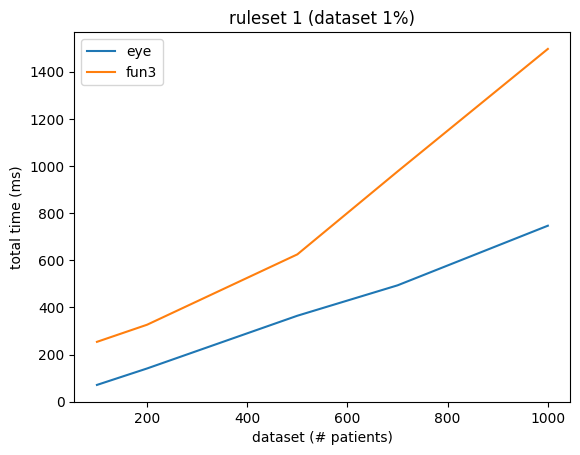

In [13]:
plot_query(0, "1%", df_eye, df_fun3)

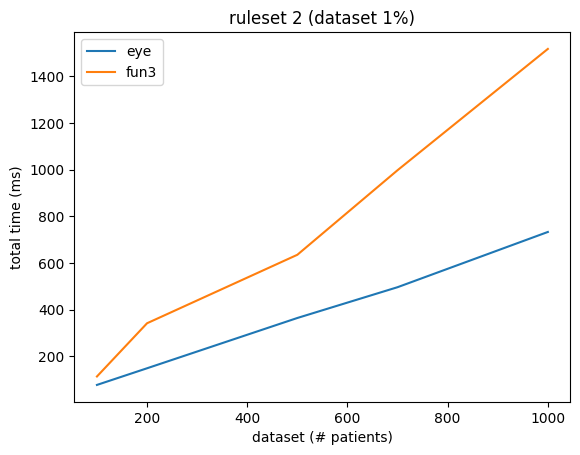

In [14]:
plot_query(1, "1%", df_eye, df_fun3)

## pt2

In [15]:
df_eye = load_n3_agg(os.path.join(path, "red", "results", "times_eye.csv"), "pt2")
df_eye

,query,data,netw_time,reas_time,total_time,query_id,data_id
1,rules_red0.n3,gen100_pt2.n3,142.8,0.0,142.8,0,100
2,rules_red0.n3,gen200_pt2.n3,262.6,1.0,263.6,0,200
3,rules_red0.n3,gen500_pt2.n3,643.0,3.0,646.0,0,500
4,rules_red0.n3,gen700_pt2.n3,977.4,4.4,981.8,0,700
0,rules_red0.n3,gen1000_pt2.n3,1394.8,7.2,1402.0,0,1000
6,rules_red1.n3,gen100_pt2.n3,147.8,0.0,147.8,1,100
7,rules_red1.n3,gen200_pt2.n3,270.6,0.0,270.6,1,200
8,rules_red1.n3,gen500_pt2.n3,636.8,1.0,637.8,1,500
9,rules_red1.n3,gen700_pt2.n3,978.2,2.2,980.4,1,700
5,rules_red1.n3,gen1000_pt2.n3,1348.6,4.4,1353.0,1,1000


In [16]:
df_eye = load_n3_agg(os.path.join(path, "red", "results", "times_eye.csv"), pt="pt2")
df_fun3 = load_n3_agg(os.path.join(path, "red", "results", "times_fun3.csv"), pt="pt2")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 680.0
avg reasoning time: 2.0
avg total time: 683.0
fun3
avg load time: 36.0
avg reasoning time: 1185.0
avg code gen time: 6.0
avg total time: 1221.0


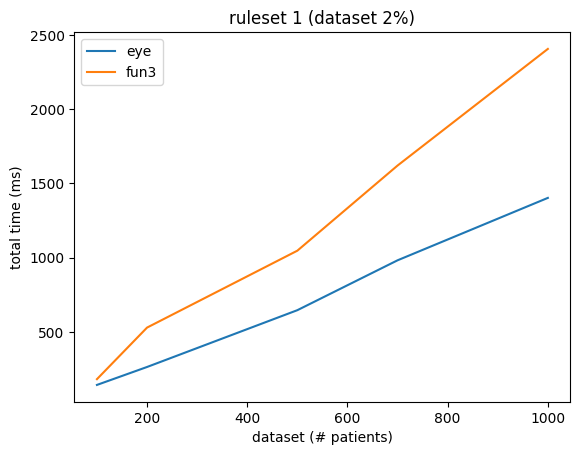

In [17]:
plot_query(0, "2%", df_eye, df_fun3)

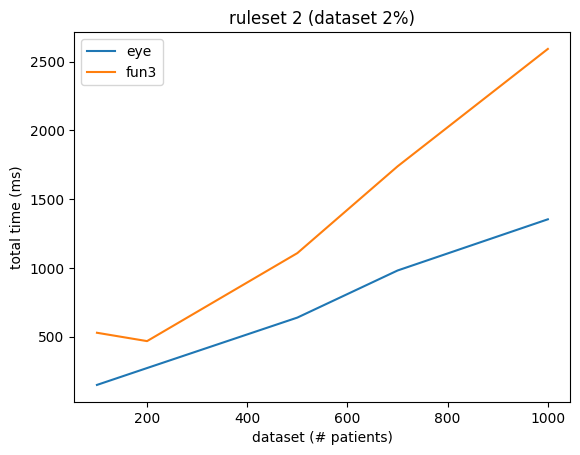

In [18]:
plot_query(1, "2%", df_eye, df_fun3)

## rule 0

In [19]:
df_eye = load_n3_agg(os.path.join(path, "red", "results", "times_eye.csv"), q="0")
df_fun3 = load_n3_agg(os.path.join(path, "red", "results", "times_fun3.csv"), q="0")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 523.0
avg reasoning time: 2.0
avg total time: 525.0
fun3
avg load time: 15.0
avg reasoning time: 931.0
avg code gen time: 1.0
avg total time: 946.0


## rule 1

In [20]:
df_eye = load_n3_agg(os.path.join(path, "red", "results", "times_eye.csv"), q="1")
df_fun3 = load_n3_agg(os.path.join(path, "red", "results", "times_fun3.csv"), q="1")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 520.0
avg reasoning time: 1.0
avg total time: 521.0
fun3
avg load time: 31.0
avg reasoning time: 973.0
avg code gen time: 10.0
avg total time: 1004.0


# sanity check

## consistency across runs

### eye

In [24]:
df_n3 = load_n3_times(os.path.join(path, "red", "results", "times_eye.csv"))
cols = ['netw_time', 'reas_time', 'total_time']
df_n3_agg = df_n3.groupby(['run'])[cols].mean().reset_index()

df_n3_agg = df_n3_agg.sort_values(by='run')
df_n3_agg

# eye
# avg load time: 521.0
# avg reasoning time: 2.0
# avg total time: 523.0

,run,netw_time,reas_time,total_time
0,0,531.20,1.55,532.75
1,1,520.40,1.65,522.05
2,2,518.90,1.60,520.50
3,3,517.30,1.55,518.85
4,4,519.45,1.55,521.00


### fun3

In [ ]:
df_n3 = load_n3_times(os.path.join(path, "red", "results", "times_fun3.csv"))
cols = ['netw_time', 'reas_time', 'total_time', 'gen_time']
df_n3_agg = df_n3.groupby(['run'])[cols].mean().reset_index()

df_n3_agg = df_n3_agg.sort_values(by='run')
df_n3_agg

# fun3
# avg load time: 23.0
# avg reasoning time: 952.0
# avg code gen time: 6.0
# avg total time: 975.0

,run,netw_time,reas_time,total_time,gen_time
0,0,10.90,984.95,995.85,3.80
1,1,55.85,915.85,971.70,8.20
2,2,9.20,972.40,981.60,3.45
3,3,29.80,935.05,964.85,8.30
4,4,9.10,951.25,960.35,4.40
